✅ Found Tar at: /kaggle/input/datasets/dschettler8845/brats-2021-task1/BraTS2021_Training_Data.tar
🚀 Opening /kaggle/input/datasets/dschettler8845/brats-2021-task1/BraTS2021_Training_Data.tar...


Extracting Files:   0%|          | 0/7508 [00:00<?, ?it/s]

/tmp/ipykernel_24/2548914354.py:112: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extract(member, path=EXTRACT_PATH)



✅ Extraction complete.
📦 Found 1251 patients.
🧠 Starting GPU-Accelerated Preprocessing...


Preprocessing:   0%|          | 0/1251 [00:00<?, ?it/s]


🎉 Done! Files are in: /kaggle/working/preprocessed


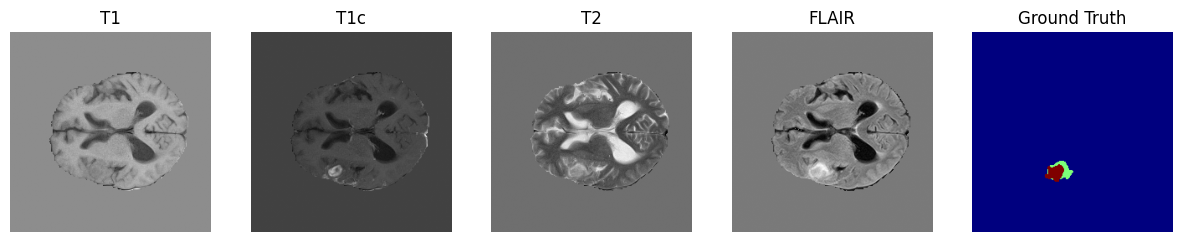

In [1]:
import os
import glob
import tarfile
import numpy as np
import nibabel as nib
import torch
from pathlib import Path
from joblib import Parallel, delayed
from tqdm.notebook import tqdm

# ==========================================
# 1. DYNAMIC CONFIGURATION & PATHS
# ==========================================
# Look for the .tar file regardless of the Kaggle dataset slug name
search_tar = glob.glob('/kaggle/input/**/BraTS2021_Training_Data.tar', recursive=True)

if not search_tar:
    raise FileNotFoundError("Could not find BraTS2021_Training_Data.tar. Please ensure the dataset is attached.")

TAR_PATH = search_tar[0]
EXTRACT_PATH = '/kaggle/temp/brats2021_raw'
OUT_DIR = '/kaggle/working/preprocessed'
TARGET_SHAPE = (240, 240, 155)

os.makedirs(EXTRACT_PATH, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

print(f"✅ Found Tar at: {TAR_PATH}")

# ==========================================
# 2. GPU ACCELERATED CORE
# ==========================================
def process_on_gpu(stacked_data, target_shape, device):
    """Performs Z-score and Pad/Crop on GPU."""
    tensor = torch.from_numpy(stacked_data).to(device).float()
    
    # Z-score Normalization (per channel)
    for c in range(tensor.shape[0]):
        channel = tensor[c]
        mask = channel > 0
        if mask.any():
            mean, std = channel[mask].mean(), channel[mask].std()
            tensor[c][mask] = (channel[mask] - mean) / (std + 1e-8)
            
    # Padding / Cropping
    c, h, w, d = tensor.shape
    th, tw, td = target_shape
    res = torch.zeros((c, th, tw, td), dtype=tensor.dtype, device=device)
    
    s_h, t_h = max(0, (h - th) // 2), max(0, (th - h) // 2)
    s_w, t_w = max(0, (w - tw) // 2), max(0, (tw - w) // 2)
    s_d, t_d = max(0, (d - td) // 2), max(0, (td - d) // 2)
    h_len, w_len, d_len = min(h, th), min(w, tw), min(d, td)
    
    res[:, t_h:t_h+h_len, t_w:t_w+w_len, t_d:t_d+d_len] = \
        tensor[:, s_h:s_h+h_len, s_w:s_w+w_len, s_d:s_d+d_len]
        
    return res.cpu().numpy()

# ==========================================
# 3. WORKER LOGIC
# ==========================================
def process_patient(p_path, p_id):
    try:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        modalities = ['_t1', '_t1ce', '_t2', '_flair']
        images = []
        affine = None
        
        # Load Modalities
        for mod in modalities:
            f_path = p_path / f"{p_id}{mod}.nii.gz"
            img_obj = nib.load(str(f_path))
            images.append(img_obj.get_fdata())
            if affine is None: affine = img_obj.affine
            
        stacked = np.stack(images, axis=0)
        final_img = process_on_gpu(stacked, TARGET_SHAPE, device)
        
        # Load & Process Segmentation
        seg_path = p_path / f"{p_id}_seg.nii.gz"
        final_seg = np.zeros(TARGET_SHAPE, dtype=np.uint8)
        if seg_path.exists():
            seg_data = nib.load(str(seg_path)).get_fdata().astype(np.uint8)
            h, w, d = seg_data.shape
            th, tw, td = TARGET_SHAPE
            sh, th_idx = max(0, (h-th)//2), max(0, (th-h)//2)
            sw, tw_idx = max(0, (w-tw)//2), max(0, (tw-w)//2)
            sd, td_idx = max(0, (d-td)//2), max(0, (td-d)//2)
            hl, wl, dl = min(h, th), min(w, tw), min(d, td)
            final_seg[th_idx:th_idx+hl, tw_idx:tw_idx+wl, td_idx:td_idx+dl] = \
                seg_data[sh:sh+hl, sw:sw+wl, sd:sd+dl]
            
        # Save compressed NPZ (Header/Affine included for inference translation)
        np.savez_compressed(f"{OUT_DIR}/{p_id}.npz", data=final_img, seg=final_seg, affine=affine)
    except Exception as e:
        pass # Skip corrupted files silently

# ==========================================
# 4. MAIN EXECUTION PIPELINE
# ==========================================
# Step A: Extraction (with Progress Bar)
if not os.listdir(EXTRACT_PATH):
    print(f"🚀 Opening {TAR_PATH}...")
    with tarfile.open(TAR_PATH, 'r') as tar:
        # Get the list of all files in the tar
        members = tar.getmembers()
        
        # Use tqdm to track the extraction of each file
        with tqdm(total=len(members), desc="Extracting Files") as pbar:
            for member in members:
                tar.extract(member, path=EXTRACT_PATH)
                pbar.update(1)
    print("\n✅ Extraction complete.")
else:
    print("✅ Dataset already extracted.")

# Step B: Recursive Discovery (The "Search" fix)
sample_flairs = glob.glob(f"{EXTRACT_PATH}/**/*_flair.nii.gz", recursive=True)
if not sample_flairs:
    raise FileNotFoundError("Could not find any NIfTI files. Check your TAR path.")

patient_dirs = [Path(f).parent for f in sample_flairs]
patient_ids = [p.name for p in patient_dirs]
print(f"📦 Found {len(patient_ids)} patients.")

# Step C: Parallel GPU Processing
print("🧠 Starting GPU-Accelerated Preprocessing...")
with tqdm(total=len(patient_ids), desc="Preprocessing") as pbar:
    Parallel(n_jobs=4, backend="threading")(
        delayed(lambda p_path, p_id: (process_patient(p_path, p_id), pbar.update(1)))(p_path, p_id)
        for p_path, p_id in zip(patient_dirs, patient_ids)
    )

print(f"\n🎉 Done! Files are in: {OUT_DIR}")

# ==========================================
# 5. OPTIONAL: VERIFICATION PLOT
# ==========================================
import matplotlib.pyplot as plt

def verify_output(p_id):
    data = np.load(f"{OUT_DIR}/{p_id}.npz")
    img, seg = data['data'], data['seg']
    slice_idx = TARGET_SHAPE[2] // 2
    
    plt.figure(figsize=(15, 5))
    titles = ['T1', 'T1c', 'T2', 'FLAIR', 'Label']
    for i in range(4):
        plt.subplot(1, 5, i+1)
        plt.imshow(img[i, :, :, slice_idx], cmap='gray')
        plt.title(titles[i])
        plt.axis('off')
    
    plt.subplot(1, 5, 5)
    plt.imshow(seg[:, :, slice_idx], cmap='jet')
    plt.title("Ground Truth")
    plt.axis('off')
    plt.show()

verify_output(patient_ids[0])